In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("personality.csv")

print("========== DATASET SHAPE ==========")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\n========== COLUMN NAMES ==========")
print(df.columns.tolist())



========== DATASET SHAPE ==========
Rows: 736
Columns: 33

========== COLUMN NAMES ==========
['Timestamp', 'Age', 'Primary streaming service', 'Hours per day', 'While working', 'Instrumentalist', 'Composer', 'Fav genre', 'Exploratory', 'Foreign languages', 'BPM', 'Frequency [Classical]', 'Frequency [Country]', 'Frequency [EDM]', 'Frequency [Folk]', 'Frequency [Gospel]', 'Frequency [Hip hop]', 'Frequency [Jazz]', 'Frequency [K pop]', 'Frequency [Latin]', 'Frequency [Lofi]', 'Frequency [Metal]', 'Frequency [Pop]', 'Frequency [R&B]', 'Frequency [Rap]', 'Frequency [Rock]', 'Frequency [Video game music]', 'Anxiety', 'Depression', 'Insomnia', 'OCD', 'Music effects', 'Permissions']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 736
Columns: 33


In [4]:
print("\n========== DATASET INFORMATION ==========")

df.info()


========== DATASET INFORMATION ==========
<class 'pandas.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     736 non-null    str    
 1   Age                           735 non-null    float64
 2   Primary streaming service     735 non-null    str    
 3   Hours per day                 736 non-null    float64
 4   While working                 733 non-null    str    
 5   Instrumentalist               732 non-null    str    
 6   Composer                      735 non-null    str    
 7   Fav genre                     736 non-null    str    
 8   Exploratory                   736 non-null    str    
 9   Foreign languages             732 non-null    str    
 10  BPM                           629 non-null    float64
 11  Frequency [Classical]         736 non-null    str    
 12  Frequency [Country]           73

In [5]:
print("\n========== NUMERICAL SUMMARY ==========")

print(df.describe())


========== NUMERICAL SUMMARY ==========
              Age  Hours per day           BPM     Anxiety  Depression  \
count  735.000000     736.000000  6.290000e+02  736.000000  736.000000   
mean    25.206803       3.572758  1.589948e+06    5.837636    4.796196   
std     12.054970       3.028199  3.987261e+07    2.793054    3.028870   
min     10.000000       0.000000  0.000000e+00    0.000000    0.000000   
25%     18.000000       2.000000  1.000000e+02    4.000000    2.000000   
50%     21.000000       3.000000  1.200000e+02    6.000000    5.000000   
75%     28.000000       5.000000  1.440000e+02    8.000000    7.000000   
max     89.000000      24.000000  1.000000e+09   10.000000   10.000000   

         Insomnia         OCD  
count  736.000000  736.000000  
mean     3.738451    2.637228  
std      3.088689    2.842017  
min      0.000000    0.000000  
25%      1.000000    0.000000  
50%      3.000000    2.000000  
75%      6.000000    5.000000  
max     10.000000   10.000000  


In [6]:
print("\n========== CATEGORICAL SUMMARY ==========")

print(df.describe(include="object"))



========== CATEGORICAL SUMMARY ==========
                 Timestamp Primary streaming service While working  \
count                  736                       735           733   
unique                 735                         6             2   
top     8/28/2022 16:15:08                   Spotify           Yes   
freq                     2                       458           579   

       Instrumentalist Composer Fav genre Exploratory Foreign languages  \
count              732      735       736         736               732   
unique               2        2        16           2                 2   
top                 No       No      Rock         Yes               Yes   
freq               497      609       188         525               404   

       Frequency [Classical] Frequency [Country]  ... Frequency [Latin]  \
count                    736                 736  ...               736   
unique                     4                   4  ...                 4   
top  

C:\Users\ADS2609024\AppData\Local\Temp\20\ipykernel_20908\3119680808.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include="object"))


In [ ]:
print("\n========== MISSING VALUES ==========")

missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])




print("\n========== MISSING VALUE PERCENTAGE ==========")

missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

print(
    missing_percentage[
        missing_percentage > 0
    ].round(2)
)




print("\n========== DUPLICATE ROWS ==========")

print(
    "Duplicate rows:",
    df.duplicated().sum()
)




df = df.drop_duplicates()

print(
    "Shape after removing duplicates:",
    df.shape
)




========== MISSING VALUES ==========
Age                            1
Primary streaming service      1
While working                  3
Instrumentalist                4
Composer                       1
Foreign languages              4
BPM                          107
Music effects                  8
dtype: int64

========== MISSING VALUE PERCENTAGE ==========
Age                           0.14
Primary streaming service     0.14
While working                 0.41
Instrumentalist               0.54
Composer                      0.14
Foreign languages             0.54
BPM                          14.54
Music effects                 1.09
dtype: float64

========== DUPLICATE ROWS ==========
Duplicate rows: 0
Shape after removing duplicates: (736, 33)



========== TARGET VALUES ==========
Music effects
Improve      542
No effect    169
Worsen        17
NaN            8
Name: count, dtype: int64

========== TARGET PERCENTAGE ==========
Music effects
Improve      73.64
No effect    22.96
Worsen        2.31
NaN           1.09
Name: proportion, dtype: float64


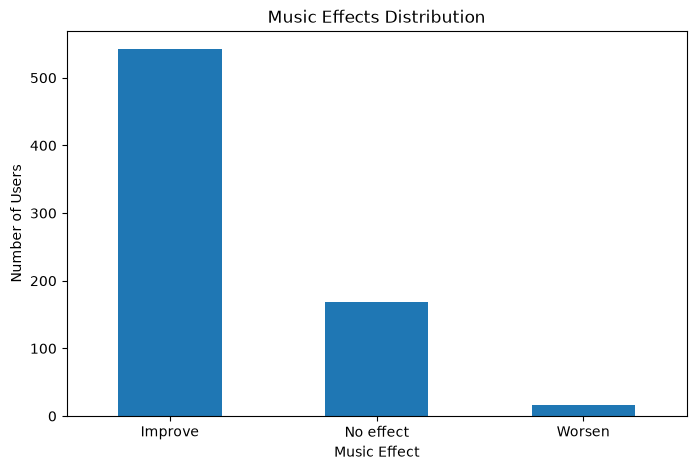

In [ ]:
target = "Music effects"




print("\n========== TARGET VALUES ==========")

print(
    df[target].value_counts(
        dropna=False
    )
)




print("\n========== TARGET PERCENTAGE ==========")

target_percentage = (
    df[target]
    .value_counts(normalize=True, dropna=False)
    * 100
)

print(target_percentage.round(2))




plt.figure(figsize=(8, 5))

df[target].value_counts().plot(
    kind="bar"
)

plt.title("Music Effects Distribution")

plt.xlabel("Music Effect")

plt.ylabel("Number of Users")

plt.xticks(rotation=0)

plt.show()

In [ ]:
df = df.dropna(
    subset=[target]
)

print(
    "\nShape after removing missing target:",
    df.shape
)



df = df.drop(
    columns=["Timestamp"],
    errors="ignore"
)




X = df.drop(
    columns=[target]
)

y = df[target]


print("\n========== FEATURES AND TARGET ==========")

print("X shape:", X.shape)

print("y shape:", y.shape)

print("\nTarget classes:")

print(y.unique())



Shape after removing missing target: (728, 33)

========== FEATURES AND TARGET ==========
X shape: (728, 31)
y shape: (728,)

Target classes:
<StringArray>
['No effect', 'Improve', 'Worsen']
Length: 3, dtype: str


In [ ]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()


print("\n========== NUMERICAL FEATURES ==========")

print(numerical_features)




categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()


print("\n========== CATEGORICAL FEATURES ==========")

print(categorical_features)




print("\n========== CATEGORICAL VALUES ==========")

for column in categorical_features:

    print("\n", column)

    print(
        X[column]
        .dropna()
        .unique()
    )




X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)


print("\n========== TRAIN TEST SPLIT ==========")

print(
    "Training rows:",
    X_train.shape[0]
)

print(
    "Testing rows:",
    X_test.shape[0]
)




========== NUMERICAL FEATURES ==========
['Age', 'Hours per day', 'BPM', 'Anxiety', 'Depression', 'Insomnia', 'OCD']

========== CATEGORICAL FEATURES ==========
['Primary streaming service', 'While working', 'Instrumentalist', 'Composer', 'Fav genre', 'Exploratory', 'Foreign languages', 'Frequency [Classical]', 'Frequency [Country]', 'Frequency [EDM]', 'Frequency [Folk]', 'Frequency [Gospel]', 'Frequency [Hip hop]', 'Frequency [Jazz]', 'Frequency [K pop]', 'Frequency [Latin]', 'Frequency [Lofi]', 'Frequency [Metal]', 'Frequency [Pop]', 'Frequency [R&B]', 'Frequency [Rap]', 'Frequency [Rock]', 'Frequency [Video game music]', 'Permissions']

========== CATEGORICAL VALUES ==========

 Primary streaming service
<StringArray>
[                          'Spotify',                     'YouTube Music',
 'I do not use a streaming service.',                       'Apple Music',
           'Other streaming service',                           'Pandora']
Length: 6, dtype: str

 While working
<Stri

C:\Users\ADS2609024\AppData\Local\Temp\20\ipykernel_20908\2598776634.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(



========== TRAIN TEST SPLIT ==========
Training rows: 582
Testing rows: 146


In [ ]:
numeric_transformer = Pipeline(

    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            MinMaxScaler()
        )
    ]
)




categorical_transformer = Pipeline(

    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)



In [12]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "numerical",
            numeric_transformer,
            numerical_features
        ),

        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)


========== MODEL TRAINING ==========
Naive Bayes model trained successfully.

========== PREDICTIONS ==========
['Improve' 'Improve' 'Improve' 'Improve' 'Improve' 'Improve' 'No effect'
 'Improve' 'Improve' 'Improve' 'No effect' 'Improve' 'Improve' 'Improve'
 'Improve' 'No effect' 'No effect' 'Improve' 'Improve' 'Improve']

Accuracy: 71.92 %
Precision: 68.82 %
Recall: 71.92 %
F1 Score: 70.19 %

========== MODEL PERFORMANCE ==========
Accuracy : 71.92 %
Precision: 68.82 %
Recall   : 71.92 %
F1 Score : 70.19 %

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

     Improve       0.79      0.85      0.82       109
   No effect       0.43      0.35      0.39        34
      Worsen       0.00      0.00      0.00         3

    accuracy                           0.72       146
   macro avg       0.41      0.40      0.40       146
weighted avg       0.69      0.72      0.70       146


========== CONFUSION MATRIX ==========
[[93 16  0]
 [22 12 

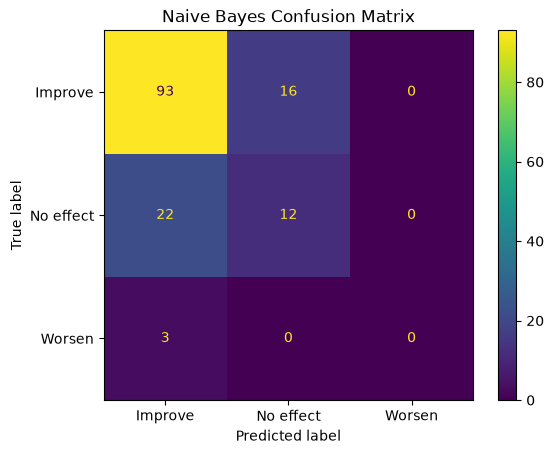

In [ ]:
nb_model = MultinomialNB()




model = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            nb_model
        )
    ]
)



print("\n========== MODEL TRAINING ==========")

model.fit(
    X_train,
    y_train
)

print(
    "Naive Bayes model trained successfully."
)




y_pred = model.predict(
    X_test
)


print("\n========== PREDICTIONS ==========")

print(y_pred[:20])




accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "\nAccuracy:",
    round(accuracy * 100, 2),
    "%"
)



precision = precision_score(

    y_test,
    y_pred,

    average="weighted",

    zero_division=0
)

print(
    "Precision:",
    round(precision * 100, 2),
    "%"
)




recall = recall_score(

    y_test,
    y_pred,

    average="weighted",

    zero_division=0
)

print(
    "Recall:",
    round(recall * 100, 2),
    "%"
)



f1 = f1_score(

    y_test,
    y_pred,

    average="weighted",

    zero_division=0
)

print(
    "F1 Score:",
    round(f1 * 100, 2),
    "%"
)




print("\n========== MODEL PERFORMANCE ==========")

print(
    "Accuracy :",
    round(accuracy * 100, 2),
    "%"
)

print(
    "Precision:",
    round(precision * 100, 2),
    "%"
)

print(
    "Recall   :",
    round(recall * 100, 2),
    "%"
)

print(
    "F1 Score :",
    round(f1 * 100, 2),
    "%"
)




print(
    "\n========== CLASSIFICATION REPORT =========="
)

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)




cm = confusion_matrix(
    y_test,
    y_pred
)

print(
    "\n========== CONFUSION MATRIX =========="
)

print(cm)




disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=model.classes_
)

disp.plot()

plt.title(
    "Naive Bayes Confusion Matrix"
)

plt.show()


In [14]:
cv_scores = cross_val_score(

    model,

    X,

    y,

    cv=5,

    scoring="accuracy"
)


print(
    "Fold Scores:",
    cv_scores
)

print(
    "Mean CV Accuracy:",
    round(
        cv_scores.mean() * 100,
        2
    ),
    "%"
)

print(
    "Standard Deviation:",
    round(
        cv_scores.std() * 100,
        2
    ),
    "%"
)



Fold Scores: [0.73972603 0.67808219 0.69863014 0.64827586 0.71034483]
Mean CV Accuracy: 69.5 %
Standard Deviation: 3.07 %


In [15]:
comparison = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": y_pred

})

print(
    "\n========== ACTUAL VS PREDICTED =========="
)

print(
    comparison.head(20)
)


========== ACTUAL VS PREDICTED ==========
       Actual  Predicted
0     Improve    Improve
1   No effect    Improve
2     Improve    Improve
3     Improve    Improve
4     Improve    Improve
5     Improve    Improve
6     Improve  No effect
7      Worsen    Improve
8     Improve    Improve
9   No effect    Improve
10    Improve  No effect
11    Improve    Improve
12    Improve    Improve
13    Improve    Improve
14  No effect    Improve
15    Improve  No effect
16    Improve  No effect
17    Improve    Improve
18    Improve    Improve
19    Improve    Improve


In [20]:
correct_predictions = (
    y_test == y_pred
).sum()

total_predictions = len(y_test)

print(
    "\nCorrect predictions:",
    correct_predictions
)

print(
    "Total predictions:",
    total_predictions
)




wrong_predictions = (
    y_test != y_pred
).sum()

print(
    "Wrong predictions:",
    wrong_predictions
)








Correct predictions: 105
Total predictions: 146
Wrong predictions: 41


In [22]:
new_user = pd.DataFrame({

    "Age": [21],

    "Primary streaming service": ["Spotify"],

    "Hours per day": [3],

    "While working": ["Yes"],

    "Instrumentalist": ["No"],

    "Composer": ["No"],

    "Fav genre": ["Pop"],

    "Exploratory": ["Yes"],

    "Foreign languages": ["Yes"],

    "BPM": [120],

    "Frequency [Classical]": ["Rarely"],

    "Frequency [Country]": ["Never"],

    "Frequency [EDM]": ["Sometimes"],

    "Frequency [Folk]": ["Never"],

    "Frequency [Gospel]": ["Never"],

    "Frequency [Hip hop]": ["Sometimes"],

    "Frequency [Jazz]": ["Rarely"],

    "Frequency [K pop]": ["Sometimes"],

    "Frequency [Latin]": ["Never"],

    "Frequency [Lofi]": ["Sometimes"],

    "Frequency [Metal]": ["Never"],

    "Frequency [Pop]": ["Very frequently"],

    "Frequency [R&B]": ["Sometimes"],

    "Frequency [Rap]": ["Sometimes"],

    "Frequency [Rock]": ["Sometimes"],

    "Frequency [Video game music]": ["Never"],

    "Anxiety": [5],

    "Depression": [3],

    "Insomnia": [2],

    "OCD": [1],

    "Permissions": ["I understand"]

})


print("New User Details:")
print("Age:", new_user["Age"].iloc[0])
print("Streaming Service:", new_user["Primary streaming service"].iloc[0])
print("Hours of Music per Day:", new_user["Hours per day"].iloc[0])
print("Favourite Genre:", new_user["Fav genre"].iloc[0])
print("Pop Frequency:", new_user["Frequency [Pop]"].iloc[0])
print("Anxiety Score:", new_user["Anxiety"].iloc[0])
print("Depression Score:", new_user["Depression"].iloc[0])



new_prediction = model.predict(
    new_user
)

print(
    "Predicted Music Effect:",
    new_prediction[0]
)




new_probability = model.predict_proba(
    new_user
)


print(
    "\n========== PREDICTION PROBABILITIES =========="
)

for class_name, probability in zip(

    model.classes_,

    new_probability[0]

):

    print(

        class_name,

        ":",

        round(
            probability * 100,
            2
        ),

        "%"
    )




print("\n============================================")
print("       FINAL NAIVE BAYES RESULTS")
print("============================================")

print(
    "Dataset rows:",
    df.shape[0]
)

print(
    "Dataset columns:",
    df.shape[1]
)

print(
    "Training rows:",
    X_train.shape[0]
)

print(
    "Testing rows:",
    X_test.shape[0]
)

print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

print(
    "Precision:",
    round(precision * 100, 2),
    "%"
)

print(
    "Recall:",
    round(recall * 100, 2),
    "%"
)

print(
    "F1 Score:",
    round(f1 * 100, 2),
    "%"
)

print(
    "5-Fold CV Accuracy:",
    round(cv_scores.mean() * 100, 2),
    "%"
)

New User Details:
Age: 21
Streaming Service: Spotify
Hours of Music per Day: 3
Favourite Genre: Pop
Pop Frequency: Very frequently
Anxiety Score: 5
Depression Score: 3
Predicted Music Effect: Improve

========== PREDICTION PROBABILITIES ==========
Improve : 89.64 %
No effect : 9.71 %
Worsen : 0.65 %

       FINAL NAIVE BAYES RESULTS
Dataset rows: 728
Dataset columns: 32
Training rows: 582
Testing rows: 146
Accuracy: 71.92 %
Precision: 68.82 %
Recall: 71.92 %
F1 Score: 70.19 %
5-Fold CV Accuracy: 69.5 %
